<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Lab: Applications of Principal Component Analysis (PCA)
Estimated time needed: **30** minutes
    

## Objectives

After completing this lab, you will be able to:

* Use Principal Component Analysis (PCA) to project 2-D data onto its principal axes
* Use PCA for feature space dimensionality reduction
* Relate explained variance to feature importance and noise reduction


# 실습: 주성분 분석(PCA) 응용 프로그램
예상 소요 시간: **30**분

## 목표

이 실습을 완료하면 다음을 수행할 수 있습니다.

* 주성분 분석(PCA)을 사용하여 2차원 데이터를 주축에 투영합니다.
* PCA를 사용하여 특징 공간 차원 축소합니다.
* 설명된 분산을 특징 중요도 및 노이즈 감소와 연관시킵니다.

## Introduction

In this lab you will explore how to implement two important applications of PCA.

1. The first application illustrates how you can use PCA to project 2-D data onto its principal axes, meaning the two orthogonal directions that explain most of the variance in your data.

2. For the second application, you will use PCA to project higher dimensional data down to a lower dimensional feature space. This is an example of dimension reduction, a powerful technique that has multiple benefits, including reducing your model-building computational load and, in many cases, the accuracy of your model. PCA can help you filter out redundant, linearly correlated variables and reduce the amount of noise in your data.


## 소개

이 실습에서는 PCA의 두 가지 중요한 응용 프로그램을 구현하는 방법을 살펴봅니다.

1. 첫 번째 응용 프로그램은 PCA를 사용하여 2차원 데이터를 주축, 즉 데이터의 분산 대부분을 설명하는 두 개의 직교 방향에 투영하는 방법을 보여줍니다.

2. 두 번째 응용 프로그램에서는 PCA를 사용하여 고차원 데이터를 저차원 특징 공간으로 투영합니다. 이는 차원 축소의 한 예이며, 모델 구축 시 계산 부하를 줄이고, 많은 경우 모델의 정확도를 높이는 등 여러 가지 이점을 제공하는 강력한 기법입니다. PCA는 중복되고 선형적으로 상관관계가 있는 변수를 필터링하고 데이터의 노이즈 양을 줄이는 데 도움이 될 수 있습니다.

# Part I: Using PCA to project 2-D data onto its principal axes
Here, you will illustrate how you can use PCA to transform your 2-D data to represent it in terms of its principal axes - the projection of your data onto the two orthogonal directions that explain most of the variance in your data. Let's see what all of this means.

# 1부: PCA를 사용하여 2차원 데이터를 주축에 투영하기
이번에는 PCA를 사용하여 2차원 데이터를 주축(데이터의 분산 대부분을 설명하는 두 개의 직교하는 방향)으로 변환하여 표현하는 방법을 알아보겠습니다. 이 모든 것이 무엇을 의미하는지 살펴보겠습니다.

Before you start, execute the cell below to make sure that the relevant libraries are available for use.

시작하기 전에 아래 셀을 실행하여 관련 라이브러리를 사용할 수 있는지 확인하세요.

In [1]:
!pip install numpy==2.2.0
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


### Load libraries
Let's begin by importing the needed libraries.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

### Create dataset
Next you'll create a 2-dimensional dataset containing two linearly correlated features.

You'll use a bivariate normal distribution.

Both features, X1 and X2, will have zero mean and a covariance given by the (symmetric) covariance matrix:

\begin{equation}
\begin{pmatrix}
  3  & 2     \\\\\\\\
  2  & 2     \\
\end{pmatrix}
\end{equation}

Here, the diagonal elements define the variances of X1 and X2 (3 and 2, respectively), while the off-diagonal element is the covariance (2) between X1 and X2, which expresses how similarly these features vary.


### 데이터 세트 생성
다음으로 선형적으로 상관된 두 개의 특성을 포함하는 2차원 데이터 세트를 생성합니다.

이변량 정규 분포를 사용합니다.

X1과 X2 두 특성 모두 평균이 0이고 공분산은 (대칭) 공분산 행렬로 주어집니다.

\begin{equation}
\begin{pmatrix}
3 & 2 \\\\\\\\
2 & 2 \\
\end{pmatrix}
\end{equation}

여기서 대각선 요소는 X1과 X2의 분산(각각 3과 2)을 정의하는 반면, 비대각선 요소는 X1과 X2 간의 공분산(2)으로, 두 특성의 차이가 얼마나 유사한지를 나타냅니다.

In [6]:
np.random.seed(42) #렌덤 숫자 생성 시드값 42
mean = [0, 0] #중심 좌표
cov = [[3, 2], [2, 2]] # 공분산 행렬 : 데이터를 어떤 모얄으로 퍼트릴 지 결정
# [3, ?]  ← x축 분산 = 3
# [?, 2]  ← y축 분산 = 2


X = np.random.multivariate_normal(mean=mean, cov=cov, size=200) # np.random.multivariate_normal(): 다변량 정규분포에서 샘플 생성
# mean=mean: 평균 [0, 0]
# cov=cov: 공분산 [[3, 2], [2, 2]]
# size=200: 200개 점 생성

### Exercise 1. Visualize the relationship between the two features.
For example, you can use a scatterplot.

### 연습 1. 두 특성 간의 관계를 시각화하세요.
예를 들어, 산점도를 사용할 수 있습니다.

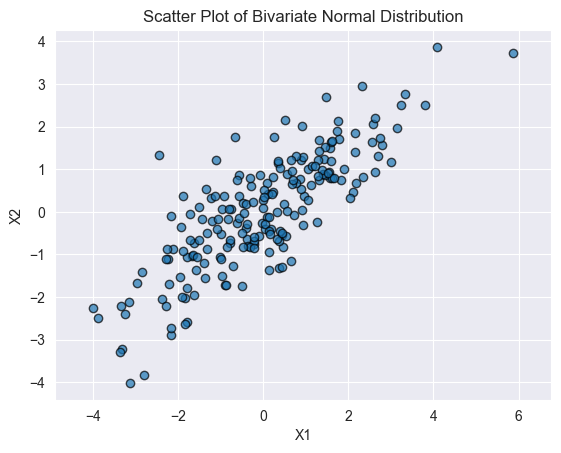

In [8]:
# enter your code here

# Scatter plot of the two features
plt.figure()
plt.scatter(X[:, 0], X[:, 1],  edgecolor='k', alpha=0.7) # 산점도 그리기
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True)
plt.show()

<details><summary>Click here for the solution</summary>

```python
# Scatter plot of the two features
plt.figure()
plt.scatter(X[:, 0], X[:, 1],  edgecolor='k', alpha=0.7)
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True)
plt.show()
```

</details>


Consider the main direction the data follows in the scatterplot. It's actually the direction of the first principal component.
You can use PCA to determine this direction.

###  Perform PCA on the dataset
Next, you'll initialize a 2-component PCA model with default parameters and then fit and transform the feature space in one step.


산점도에서 데이터가 따르는 주요 방향을 고려해 보세요. 실제로는 첫 번째 주성분의 방향입니다.
PCA를 사용하여 이 방향을 확인할 수 있습니다.

### 데이터세트에 PCA 수행
다음으로, 기본 매개변수를 사용하여 2-성분 PCA 모델을 초기화한 다음, 한 단계로 특성 공간을 적합하고 변환합니다.

In [10]:
#PCA = Principal Component Analysis (주성분 분석)
# 사용 목적 PCA는 데이터가 가장 많이 퍼져있는 방향을 찾는다
pca = PCA(n_components=2) # n_components=2 2개의 주성분을 찾는다
X_pca = pca.fit_transform(X) # .fit_transform() 분해

### Get the principal components from the model. 
The principal components are the principal axes, represented in feature space coordinates, 
which align with the directions of maximum variance in your data.

### 모델에서 주성분을 가져옵니다.
주성분은 특징 공간 좌표로 표현되는 주축이며,
데이터의 최대 분산 방향과 일치합니다.

In [11]:
components = pca.components_
components

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

The principal components are sorted in decreasing order by their explained variance, which can be expressed as a ratio:


주성분은 설명 분산을 기준으로 내림차순으로 정렬되며, 이는 비율로 표현될 수 있습니다.

In [12]:
pca.explained_variance_ratio_ #주성분의 바율 확인
# array([0.9111946, 0.0888054]) 첫번쨰 주성부이 거의 모든 패턴을 지님

array([0.9111946, 0.0888054])

### Exercise 2. What percentage of the variance in the data is explained by the first principal component?
### 연습문제 2. 첫 번째 주성분은 데이터 분산의 몇 퍼센트를 설명합니까?

Enter your answer here


<details><summary>Click here for the solution</summary>
You can see that the first component explains over 90% of the variance in the data, while the second explains about 9%.
</details>


### Display the results
Here, you'll use a scatterplot to display the data points in their original feature space, X1, X2.

You'll also plot the projections of the data points onto their principal component directions.

It's a bit technical, requiring some understanding of linear algebra, but the outcome will be instructive.

Let's see how this works.

#### Project the data onto its principal component axes
The projection of the data onto a given principal component yields the coordinates of each of the data points along that component's direction. 

The new coordinates are given by the dot products of each point's coordinates with the given PCA component. 

Specifically, the projections are given by:

### 결과 표시
여기서는 산점도를 사용하여 원래 특징 공간 X1, X2에 있는 데이터 포인트를 표시합니다.

또한 데이터 포인트를 주성분 방향에 투영하여 표시합니다.

선형 대수에 대한 이해가 필요한 다소 기술적이지만, 결과는 유익할 것입니다.

작동 방식을 살펴보겠습니다.

#### 데이터를 주성분 축에 투영합니다.
주어진 주성분에 데이터를 투영하면 해당 성분 방향을 따라 각 데이터 포인트의 좌표가 생성됩니다.

새로운 좌표는 각 포인트 좌표와 주어진 PCA 성분의 내적으로 주어집니다.

구체적으로 투영은 다음과 같습니다.

In [13]:
projection_pc1 = np.dot(X, components[0])
projection_pc2 = np.dot(X, components[1])

Now that you have these coordinates, you can use them to represent the projections of each data point along the principal directions in the original feature space.

In code:


In [14]:
x_pc1 = projection_pc1 * components[0][0]
y_pc1 = projection_pc1 * components[0][1]
x_pc2 = projection_pc2 * components[1][0]
y_pc2 = projection_pc2 * components[1][1]

#### Plot the results
Now let's visualize this.


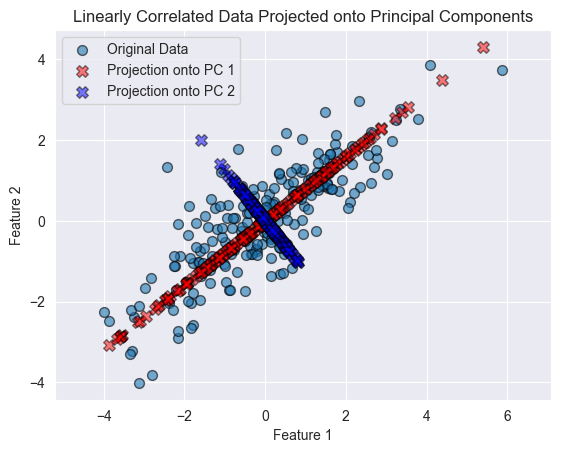

In [15]:
# Plot original data
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

# Plot the projections along PC1 and PC2
# PC1 and PC2은 좌표
plt.scatter(x_pc1, y_pc1, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 1')
plt.scatter(x_pc2, y_pc2, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

It took some effort but now you can see what the the principal coordinates mean.

The data varies in two main directions. 
- The first direction, in red, is aligned in the direction having the widest variation.

### Exercise 3. Describe the second direction.

약간의 노력이 필요했지만 이제 주 좌표가 무엇을 의미하는지 알 수 있습니다.

데이터는 두 가지 주요 방향으로 변화합니다.
- 빨간색으로 표시된 첫 번째 방향은 변화가 가장 큰 방향에 정렬됩니다.

### 연습 문제 3. 두 번째 방향을 설명하세요.

Enter your answer here


<details><summary>Click here for the solution</summary>
The second direction, in blue, is perpendicular to first and has a lower variance.<br>
파란색으로 표시된 두 번째 방향은 첫 번째 방향과 수직이며 분산이 더 낮습니다.
</details>


# Part II. PCA for feature space dimensionality reduction
For this second application, you'll use PCA to project the four-dimensional Iris feature data set down onto a two-dimensional feature space.

This will have the added benefit of enabling you to visualize some of the most important structures in the dataset.

# 2부. 특징 공간 차원 축소를 위한 PCA
이 두 번째 응용 프로그램에서는 PCA를 사용하여 4차원 붓꽃 특징 데이터 세트를 2차원 특징 공간에 투영합니다.

이를 통해 데이터 세트에서 가장 중요한 구조 중 일부를 시각화할 수 있다는 추가적인 이점이 있습니다.

### Load and preprocess Iris data
Let's start by loading the iris data and standardizing is features.

### 붓꽃 데이터 불러오기 및 전처리
붓꽃 데이터를 불러오고 특징을 표준화하는 것부터 시작해 보겠습니다.

In [16]:
# Load the Iris dataset
iris = datasets.load_iris() # Iris 데이터셋 에제 로드
X = iris.data  # 특성 데이터
y = iris.target # 레이블
target_names = iris.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Exercise 4. What are the Iris flower's names?


In [17]:
# Enter your code here
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

<details><summary>Click here for the solution</summary>

```python

iris.target_names

```

</details>


### Exercise 5. Initialize a PCA model and reduce the Iris data set dimensionality to two components


### 연습문제 5. PCA 모델을 초기화하고 Iris 데이터 세트의 차원을 두 개의 구성 요소로 줄입니다.

In [18]:
# Enter your code here
# Apply PCA and reduce the dataset to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

<details><summary>Click here for the solution</summary>

```python

# Apply PCA and reduce the dataset to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

```

</details>


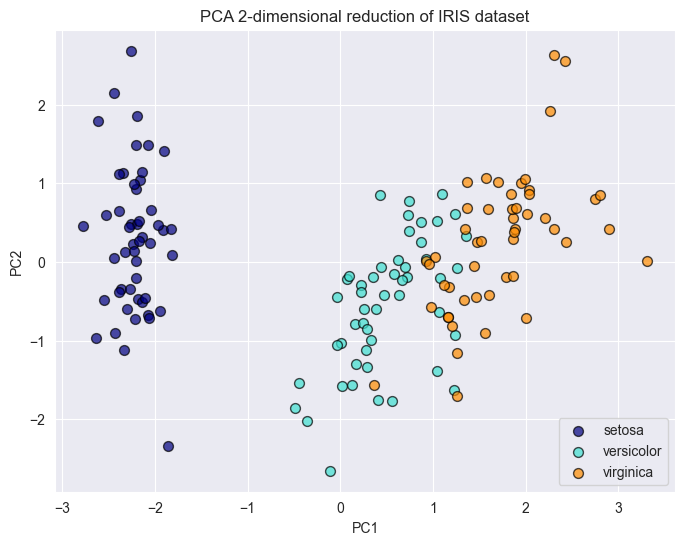

In [21]:
# Plot the PCA-transformed data in 2D
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, s=50, ec='k',alpha=0.7, lw=lw,
                label=target_name)

plt.title('PCA 2-dimensional reduction of IRIS dataset',)
plt.xlabel("PC1",)
plt.ylabel("PC2",)
plt.legend(loc='best', shadow=False, scatterpoints=1,)
# plt.grid(True)
plt.show()

## Reflection
Examine the plot and consider how well the Iris classes have been separated simply by projecting the feature space down to two principal components.

## 반영
플롯을 검토하고 특징 공간을 두 개의 주성분으로 투영함으로써 Iris 클래스가 얼마나 잘 분리되었는지 생각해 보세요.

### Exercise 6. What percentage of the original feature space variance do these two combined principal components explain?

### 연습문제 6. 이 두 가지 주성분의 결합은 원래 특성 공간 분산의 몇 퍼센트를 설명합니까?

In [25]:
# Enter your code here

# hint - add the individual values
100*pca.explained_variance_ratio_.sum()


np.float64(95.81320720000164)

<details><summary>Click here for the solution</summary>

```python

100*pca.explained_variance_ratio_.sum()
```

</details>


## A deeper look at the explained variances
In this next and final set of exercises, your goal is to:
- Acquire and plot the PCA-explained variance ratios for all four Iris features as a barplot
- Overlay the cummulative explained variance

### Exercise 7. Reinitialize the PCA model without reducing the dimension
Standardize the Iris data, and fit and transform the scaled data.


## 설명된 분산에 대한 심층 분석
다음이자 마지막 연습 문제 세트의 목표는 다음과 같습니다.
- 네 가지 Iris 특성 모두에 대한 PCA 설명 분산 비율을 막대 그래프로 수집하고 표시합니다.
- 누적 설명된 분산을 겹쳐 표시합니다.

### 연습 문제 7. 차원을 줄이지 않고 PCA 모델을 다시 초기화합니다.
Iris 데이터를 표준화하고, 스케일링된 데이터를 적합하고 변환합니다.

In [26]:
# Enter your code here

# Standardize the data
# 표준화 작업
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
# # n_components 지정 안 함 → 모든 주성분
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

<details><summary>Click here for the solution</summary>

```python

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
```

</details>


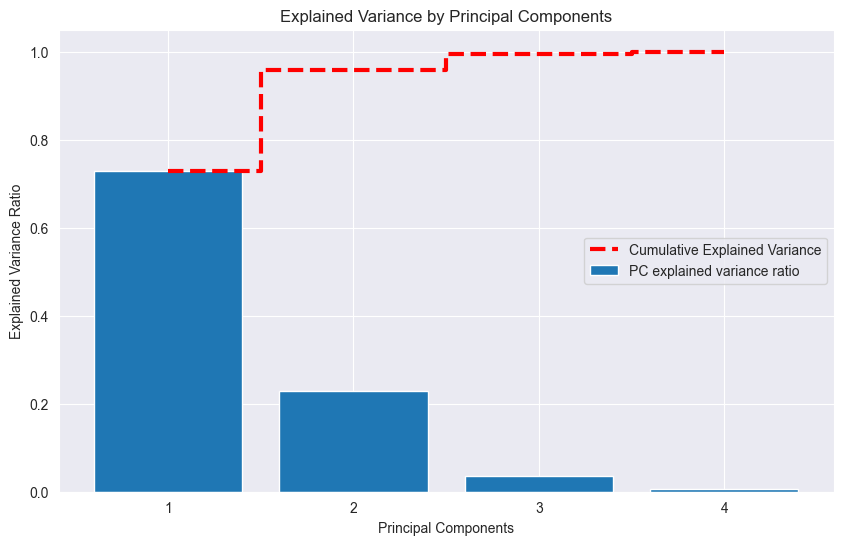

In [27]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_ #각 주성분의 설명 비율

# Plot explained variance ratio for each component
plt.figure(figsize=(10,6))
plt.bar(x=range(1, len(explained_variance_ratio)+1), height=explained_variance_ratio, alpha=1, align='center', label='PC explained variance ratio' )
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')

# 계단선 (누적 설명 비율)
# Plot cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, 5), cumulative_variance, where='mid', linestyle='--', lw=3,color='red', label='Cumulative Explained Variance')
# Only display integer ticks on the x-axis
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)
plt.show()

Here are some considerations:
- What does the red dashed line indicate to you?
- What would you consider doing if your wanted to suppress some noise in your data?

다음은 몇 가지 고려 사항입니다.
- 빨간색 점선은 무엇을 나타내나요?
- 데이터의 노이즈를 억제하려면 어떻게 해야 하나요?

### Congratulations! You're ready to move on to your next lesson!


## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>


### Other Contributors

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>


<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-05 | 1.0  | Jeff Grossman    | Create content  | -->



## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
